In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
import pycountry
import geopandas as gpd
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import textwrap
import fiona

from src.text_processing_functions import *
from src.LLM_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *
from src.hazard_def import *
from src.impact_def import *
from src.ImpactRegistry import Impacts
from src.impact_def import IMPACT_SUBTYPE_MERGER, IMPACT_SUBTYPES_MERGED

path_save_fig = DATA_FIGURE / "data_overview"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# 200 reports 
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "post_processed_all_appeals_unique_1-333_meta-llama_llama-4-scout-17b-16e-instruct_v281025"
# res_name_llm = "post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
# res_name_llm = "merged_subtypes_post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
# res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v230426_geo"
# res_name_llm = "filter_post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v230426_geo"
res_name_llm = "filter_merged_post_processed_0-778_llm_response_preproc_text_sel_gaps_combined_v300626_v060726_2016-2025_meta-llama_llama-4-scout-17b-16e-instruct_v060726_v080726_geo"

# df_llm_all_geo = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')
df_llm_all_geo = pd.read_parquet(os.path.join(DATA_OUT_PROC, res_name_llm+'.parquet'))
df_llm_all_geo = df_llm_all_geo.drop(columns=["geometry"])
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), engine="fiona")
# df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC / (res_name_llm+'.parquet'))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

# col_to_list = ["location", "country_iso3", "hazards"]
# df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

In [33]:
df_llm_all_geo.locationLowestAdmin.value_counts()/(len(df_llm_all_geo.locationLowestAdmin))

locationLowestAdmin
ADM_0    0.562439
ADM_1    0.309436
ADM_2    0.127086
Name: count, dtype: float64

In [5]:
# Import 
world = gpd.read_file(ADMIN_PATH / "ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
# admin1 = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_admin_1_states_provinces/"+'ne_10m_admin_1_states_provinces.shp')
# rivers = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_rivers_lake_centerlines/"+'ne_10m_rivers_lake_centerlines.shp')
# cities = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_populated_places/"+'ne_10m_populated_places.shp')

In [6]:
def get_continent(iso_code, world):
    try:
        return world[world['ISO_A3'] == iso_code]['CONTINENT'].values[0]
    except IndexError:
        return None

In [7]:
continent_offsets = {
    'Africa': (0, -0.20),
    'Asia': (0.15, -0.05),
    'Europe': (-0.15, -0.02),
    'Oceania' : (0.08, 0.02),
    'North America' : (-0.05, -0.15),
    'South America' : (-0.05, -0.02)
}

# Hazard Map

In [8]:
hazard_colormap = {
    # 🔥 Environmental & Climatic
    'Drought': '#C2B280',                # sandy beige — dry/arid land
    'Wildfire': '#D1495B',               # strong red — fire and danger
    'Extreme warm temperature': '#E26D5A',# coral/orange — heat
    'Extreme cold temperature': '#A6CEE3',# icy blue — cold

    # 🌋 Geophysical
    'Earthquake': '#7F7F7F',             # neutral gray — ground rupture
    'Mass movement': '#8C564B',          # earthy brown — landslides
    'Volcanic activity': '#E17C05',      # lava orange — volcanic tones

    # 🌊 Hydrological / Meteorological
    'Flood': '#1F77B4',                  # deep blue — water/flood
    'Wave action': '#17BECF',            # cyan — ocean/wave
    'Tropical storm': '#2CA02C',         # green — tropical vegetation/storm
    'Convective storm': '#5B8E7D',       # teal — thunderstorm tone
    'Other storm': '#BCBD22',            # olive — extratropical/windstorm

    # ☣️ Biological / Social
    'Epidemic': '#E377C2',               # magenta — biological hazard
    'Conflict': '#7F3121'                # dark red-brown — violence/unrest
}

hazard_order = list(hazard_colormap.keys())

In [50]:
all_reports_grp = df_llm_all_geo.explode('country_iso3').groupby('appealCode').agg(iso_code = ("country_iso3", "first")).reset_index()

In [ ]:
# all_reports_country_count = all_reports_grp.groupby("iso_code").agg(appeal_count = ("appealCode", "nunique"))

In [51]:
# df = pd.DataFrame(list(country_appeal_count.items()), columns=["iso_code", "appeal_count"])
world_2 = world.merge(all_reports_grp, how="left", left_on="ISO_A3", right_on="iso_code")

In [55]:
df_llm_all_geo["continent"] = df_llm_all_geo["country_iso3"].apply(
    lambda iso_list: list({get_continent(iso, world_2) for iso in iso_list if iso})
    if isinstance(iso_list, (list, np.ndarray)) else None
)

# Filter out rows without continent
valid_continents = df_llm_all_geo.dropna(subset=['continent'])
df = valid_continents.explode('continent').explode('hazards')
df = df.dropna(subset=['continent', 'hazards'])
df_unique = df.drop_duplicates(subset=['appealCode', 'continent', 'hazards'])

# Group and count number of unique appeals per continent and hazard
hazard_counts = (
    df_unique
    .groupby(['continent', 'hazards'])['appealCode']
    .nunique()   # count unique appeal codes
    .unstack(fill_value=0)
)

# One row per appeal and continent (regardless of hazards)
continent_totals = (
    valid_continents
    .explode("continent")
    .dropna(subset=["continent"])
    .drop_duplicates(subset=["appealCode", "continent"])
    .groupby("continent")["appealCode"]
    .nunique()
    .reindex(continent_order)
)

hazard_counts_total = continent_totals

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_10640\1683944600.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')


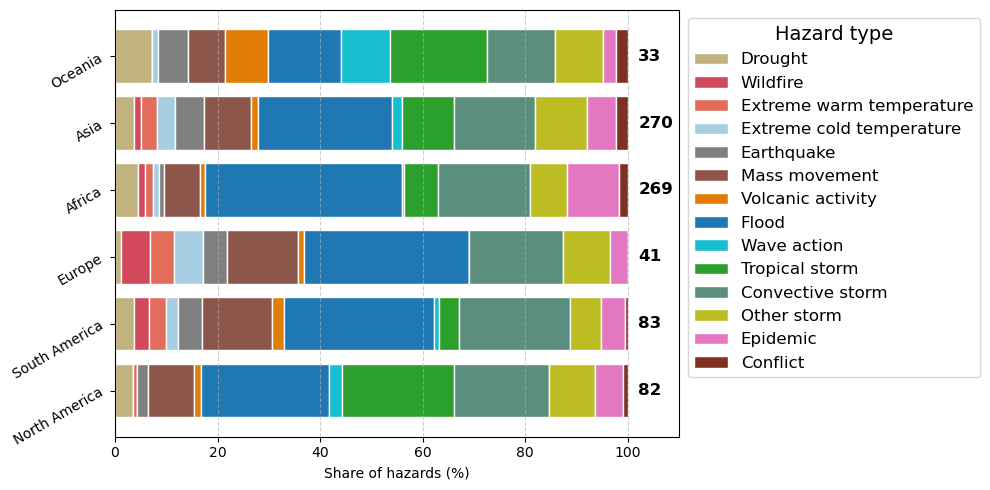

In [57]:
continent_order = ['North America', 'South America', 'Europe', 'Africa', 'Asia',  'Oceania']

# Ensure the columns follow the order of hazard_colormap
# hazard_order = [h for h in hazard_colormap.keys() if h in hazard_counts.columns]
hazard_counts = hazard_counts.loc[continent_order]
hazard_counts = hazard_counts[hazard_order]

# Convert to percentage per continent
hazard_counts_percent = hazard_counts.div(hazard_counts.sum(axis=1), axis=0) * 100
# hazard_counts_total = hazard_counts.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

left = [0] * len(hazard_counts)
for hazard in hazard_counts.columns:
    ax.barh(
        hazard_counts.index,
        hazard_counts_percent[hazard],
        left=left,
        color=hazard_colormap.get(hazard, 'gray'),
        edgecolor='white',
        label=hazard
    )
    left += hazard_counts_percent[hazard].values

# Add total counts at end of each bar
for i, total in enumerate(hazard_counts_total):
    ax.text(102, i, f'{total}', va='center', fontsize=12, fontweight='bold')

# Formatting
ax.set_xlim(0, 110)
ax.set_xlabel('Share of hazards (%)')
ax.set_ylabel('')
# ax.set_title('Distribution of Hazard Types by Continent', fontweight='bold')

# Add vertical gridlines from x-axis
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

# Rotate y-axis labels slightly
ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')

# Legend
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Hazard type', title_fontsize=14, fontsize=12)

# Save fig
fig.savefig(path_save_fig / f"hazard_share_continents.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.pdf", 
            format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# Impact Map

In [23]:
impact_colormap = {
    'Human': '#B23A2E',                             # Red — human impacts
    'Infrastructure and Service access': '#5C7A6E', # Blue — buildings, roads, utilities
    'Economy & Culture': '#B97F3B',  # Orange — economy/business
}

In [24]:
def merge_impact_subtypes(df, column="impactSubtype"):
    df = df.copy()

    for merged_name, pattern in IMPACT_SUBTYPE_MERGER.items():
        mask = df[column].str.contains(pattern, regex=True, na=False)
        df.loc[mask, column] = merged_name

    return df

In [25]:
# Step 0: Get mapping dict from subtype → main type
# impact_subtype_to_main = Impacts.get_main_types()  # Already a dict

# Step 1: Map each impactSubtype in your DataFrame
df_llm_all_geo = merge_impact_subtypes(df_llm_all_geo, column="impactSubtype")
df_llm_all_geo['impact_main_type'] = df_llm_all_geo['impactSubtype'].map(IMPACT_TYPES_MERGED)

# Optional: check for unmapped subtypes
unmapped = df_llm_all_geo.loc[df_llm_all_geo['impact_main_type'].isna(), 'impactSubtype'].unique()
if len(unmapped) > 0:
    print("⚠️ Unmapped impact subtypes:", unmapped)

# --- Step 2: Now you can safely count per appeal ---
all_report_count = (
    df_llm_all_geo
    .explode('country_iso3')
    .groupby(['appealCode', "impact_main_type"])
    .agg(
        impact_number=("impactSubtype", "count"),   # total number of impact entries
        iso_code=("country_iso3", "first")
    )
    .reset_index()
)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_10640\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[column].str.contains(pattern, regex=True, na=False)
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_10640\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[column].str.contains(pattern, regex=True, na=False)
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_10640\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[column].str.contains(pattern, regex=True, na=False)
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_10640\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extra

In [26]:
# all_report_impact_count = all_report_count.groupby(["iso_code", "impact_main_type"]).agg(impact_count = ("impact_number", "sum")).reset_index()
all_report_impact_count = all_report_count.groupby(["iso_code"]).agg(impact_count = ("impact_number", "sum")).reset_index()
all_report_impact_maintype_count = all_report_count.groupby(["iso_code", "impact_main_type"]).agg(impact_count = ("impact_number", "sum")).reset_index()

In [27]:
all_reports_impactsubtype = df_llm_all_geo.groupby(["impactSubtype"]).agg(impact_subtype_count = ("country_iso3", "count"), impact_main_type = ("impact_main_type", "first")).reset_index()
all_reports_impactsubtype['color'] = all_reports_impactsubtype['impact_main_type'].map(impact_colormap)
all_reports_impactsubtype = all_reports_impactsubtype.dropna(subset=["color"])
all_reports_impactsubtype = all_reports_impactsubtype.set_index('impactSubtype')
all_reports_impactsubtype = all_reports_impactsubtype.loc[
    [s for s in IMPACT_SUBTYPES_MERGED if s in all_reports_impactsubtype.index]
].reset_index()

In [28]:
world_impact = world.merge(all_report_impact_count, how="left", left_on="ISO_A3", right_on="iso_code")

In [45]:
len(world_impact.loc[world_impact["impact_count"]>0])

145

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_10640\3203735077.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


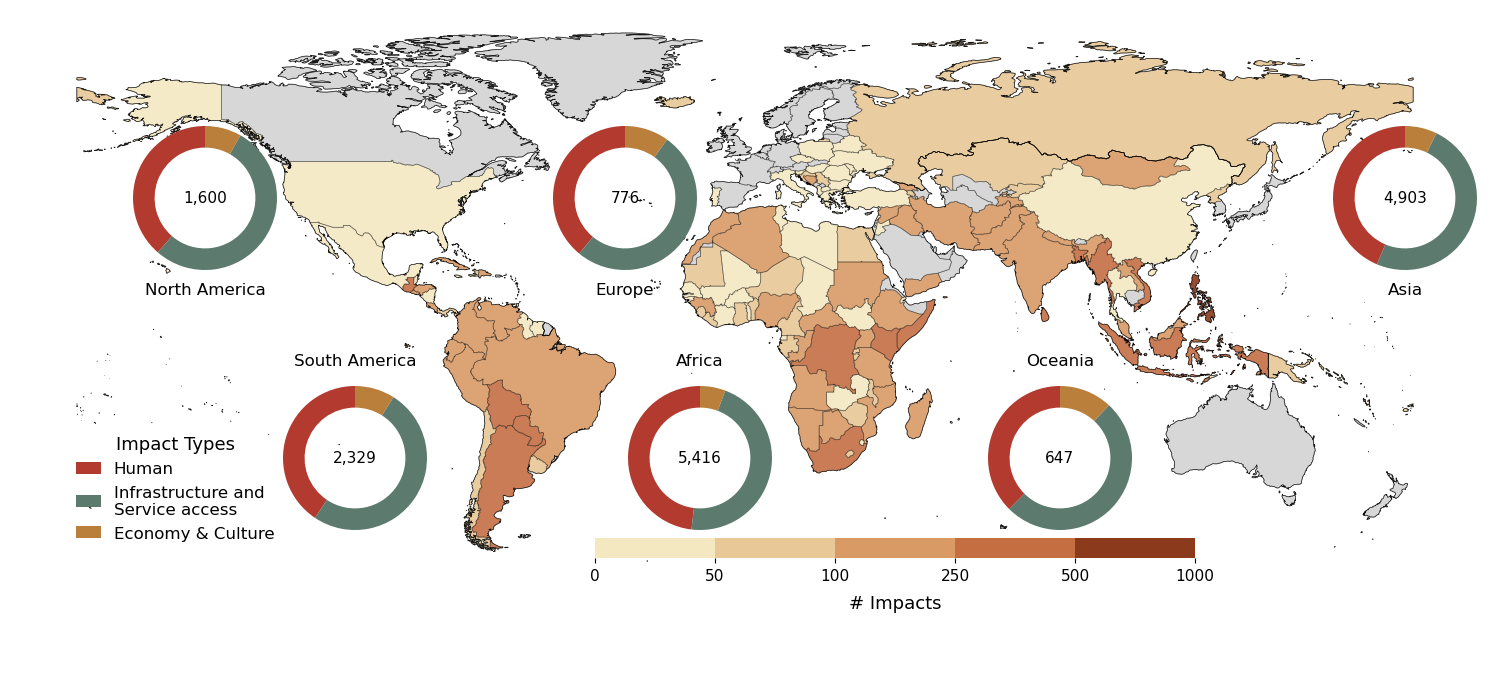

In [29]:
# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

ax.set_ylim(-60, 90)

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.4)

# # Color map for choropleth
# sequential_cmap = LinearSegmentedColormap.from_list(
#     "warm_earth_seq",
#     ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"],
#     N=256
# )

colors_5 = ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"]
cmap_5 = ListedColormap(colors_5, name="warm_earth_5")

values = world_impact["impact_count"].dropna()

# 5 classes → 6 boundaries
# bounds = np.quantile(values, [0.02, 0.22, 0.42, 0.62, 0.82, 0.98])
bounds = [0, 50, 100, 250, 500, 1000]

norm = BoundaryNorm(bounds, cmap_5.N)

world_impact.plot(
    column="impact_count",
    ax=ax,
    cmap=cmap_5,
    norm=norm,
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    alpha=0.9
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap_5, norm=norm)
sm._A = []
cbar_ax = fig.add_axes([0.4, 0.23, 0.4, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
cbar.ax.tick_params(labelsize=11)
cbar.outline.set_visible(False)
cbar.set_label("# Impacts", fontsize=13, labelpad=8)

ax.set_axis_off()

# Prepare continent data
all_report_impact_count_clean = all_report_impact_maintype_count.reset_index()
all_report_impact_count_clean['continent'] = all_report_impact_count_clean['iso_code'].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)

continent_shapes = world_impact.dissolve(by='CONTINENT')
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)

# Add continents boundaries
continent_shapes.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=0.8)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

# Calculate impact percentages per continent
continent_impact_counts = (
    all_report_impact_count_clean
    .groupby(['continent', 'impact_main_type'])['impact_count']
    .sum()
    .unstack(fill_value=0)
)

# Order columns and calculate percentages
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)
continent_impact_pct = continent_impact_counts.div(continent_impact_counts.sum(axis=1), axis=0) * 100

# Continent position offsets for donut charts
continent_offsets = {
    'Africa': (0.38, 0.24),
    'Asia': (0.85, 0.50),
    'Europe': (0.33, 0.50),
    'North America': (0.05, 0.50),
    'Oceania': (0.62, 0.24),
    'South America': (0.15, 0.24)
}

# Plot donut charts for each continent
for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_pct.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    # Get position offsets
    x_value, y_value = continent_offsets.get(continent, (0, 0))

    # Create axis for donut chart
    ax_donut = fig.add_axes([x_value, y_value, 0.18, 0.18])
    ax_donut.set_facecolor('white')
    ax_donut.patch.set_alpha(0.7)
    
    # Impact data
    impact_data = continent_impact_pct.loc[continent]
    impact_data = impact_data[impact_data > 0]
    impact_labels = impact_data.index
    impact_sizes = impact_data.values
    impact_colors = [impact_colormap.get(label, '#BBBBBB') for label in impact_labels]

    # Impact donut
    # wedges_impact, _ = ax_donut.pie(impact_sizes, colors=['#DDDDDD'] * len(impact_sizes), startangle=90, wedgeprops=dict(width=0.45))
    wedges_impact, _ = ax_donut.pie(impact_sizes, colors=impact_colors, startangle=90, wedgeprops=dict(width=0.3))
    
    # Add the total impact value 
    total_impacts = int(continent_impact_counts.loc[continent].sum())
    ax_donut.text(
        0, 0, f'{total_impacts:,}',  # center text
        ha='center', va='center',
        fontsize=11, color='black'
    )

    #Make the donus
    for i, (size, wedge) in enumerate(zip(impact_sizes, wedges_impact)):
        if size >= 10:
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = 0.5 * np.cos(np.radians(angle))
            y = 0.5 * np.sin(np.radians(angle))

    # Remove axis frame
    ax_donut.set_frame_on(False)
    ax_donut.set_xticks([])
    ax_donut.set_yticks([])

    if continent in ['North America', 'Asia', 'Europe'] :
        ax_donut.set_title(continent, fontsize=12, pad=2, y=-0.05)
    else : 
        ax_donut.set_title(continent, fontsize=12, pad=2, y=1)

# Add impact legend for impact types
wrapped_labels = {
    impact: '\n'.join(textwrap.wrap(impact, width=20))  # adjust width as needed
    for impact in impact_order if impact in impact_colormap
}

legend_ax = fig.add_axes([0.02, 0.1, 0.2, 0.4])
legend_ax.set_facecolor('white')
legend_ax.patch.set_alpha(0.8)

# Create legend elements with wrapped labels
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=impact_colormap[impact], label=wrapped_labels[impact])
    for impact in impact_order if impact in impact_colormap
]

# Add legend (allowing multiple columns if many elements)
legend_ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=12,
    title='Impact Types',
    title_fontsize=13,
    ncol=1,               # 🔹 split legend into 2 columns if long
    columnspacing=1.5,
    handlelength=1.5
)
legend_ax.set_axis_off()

# # Add barplot of impact subtypes 
# barplot_subtype_ax = fig.add_axes([0.05, -0.20, 0.9, 0.4])
# barplot_subtype_ax.set_facecolor('white')
# barplot_subtype_ax.patch.set_alpha(0)

# impact_order = list(impact_colormap.keys())

# all_reports_impactsubtype['impact_main_type'] = (
#     pd.Categorical(
#         all_reports_impactsubtype['impact_main_type'],
#         categories=impact_order,
#         ordered=True
#     )
# )

# # Sort by: category (circle plot order) → subtype count (descending)
# all_reports_impactsubtype_sorted = (
#     all_reports_impactsubtype
#     .sort_values(by=["impact_main_type", "impact_subtype_count"],
#                  ascending=[True, False])
#     .reset_index(drop=True)
# )

# barplot_subtype_ax.bar(
#     x=all_reports_impactsubtype_sorted['impactSubtype'],
#     height=all_reports_impactsubtype_sorted['impact_subtype_count'],
#     color=all_reports_impactsubtype_sorted['color'],
#     edgecolor='black'
# )

# # Rotate and add y labels
# wrapped_labels = [
#     '\n'.join(textwrap.wrap(label, width=30))  # creates multi-line if long
#     for label in all_reports_impactsubtype_sorted['impactSubtype']
# ]
# barplot_subtype_ax.set_xticks(range(len(all_reports_impactsubtype_sorted)))
# barplot_subtype_ax.set_xticklabels(wrapped_labels, rotation=35, ha='right')

# # Optional: improve layout and readability
# barplot_subtype_ax.tick_params(axis='x', labelsize=9)
# for spine in barplot_subtype_ax.spines.values():
#     spine.set_visible(False)
# barplot_subtype_ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.7)
# barplot_subtype_ax.set_ylabel('# Impact', fontsize=13)

plt.tight_layout()
# fig.savefig(path_save_fig / f"impact_map_only.png", 
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"impact_map_only.svg", 
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"impact_map_only.pdf", 
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_10640\2010026450.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


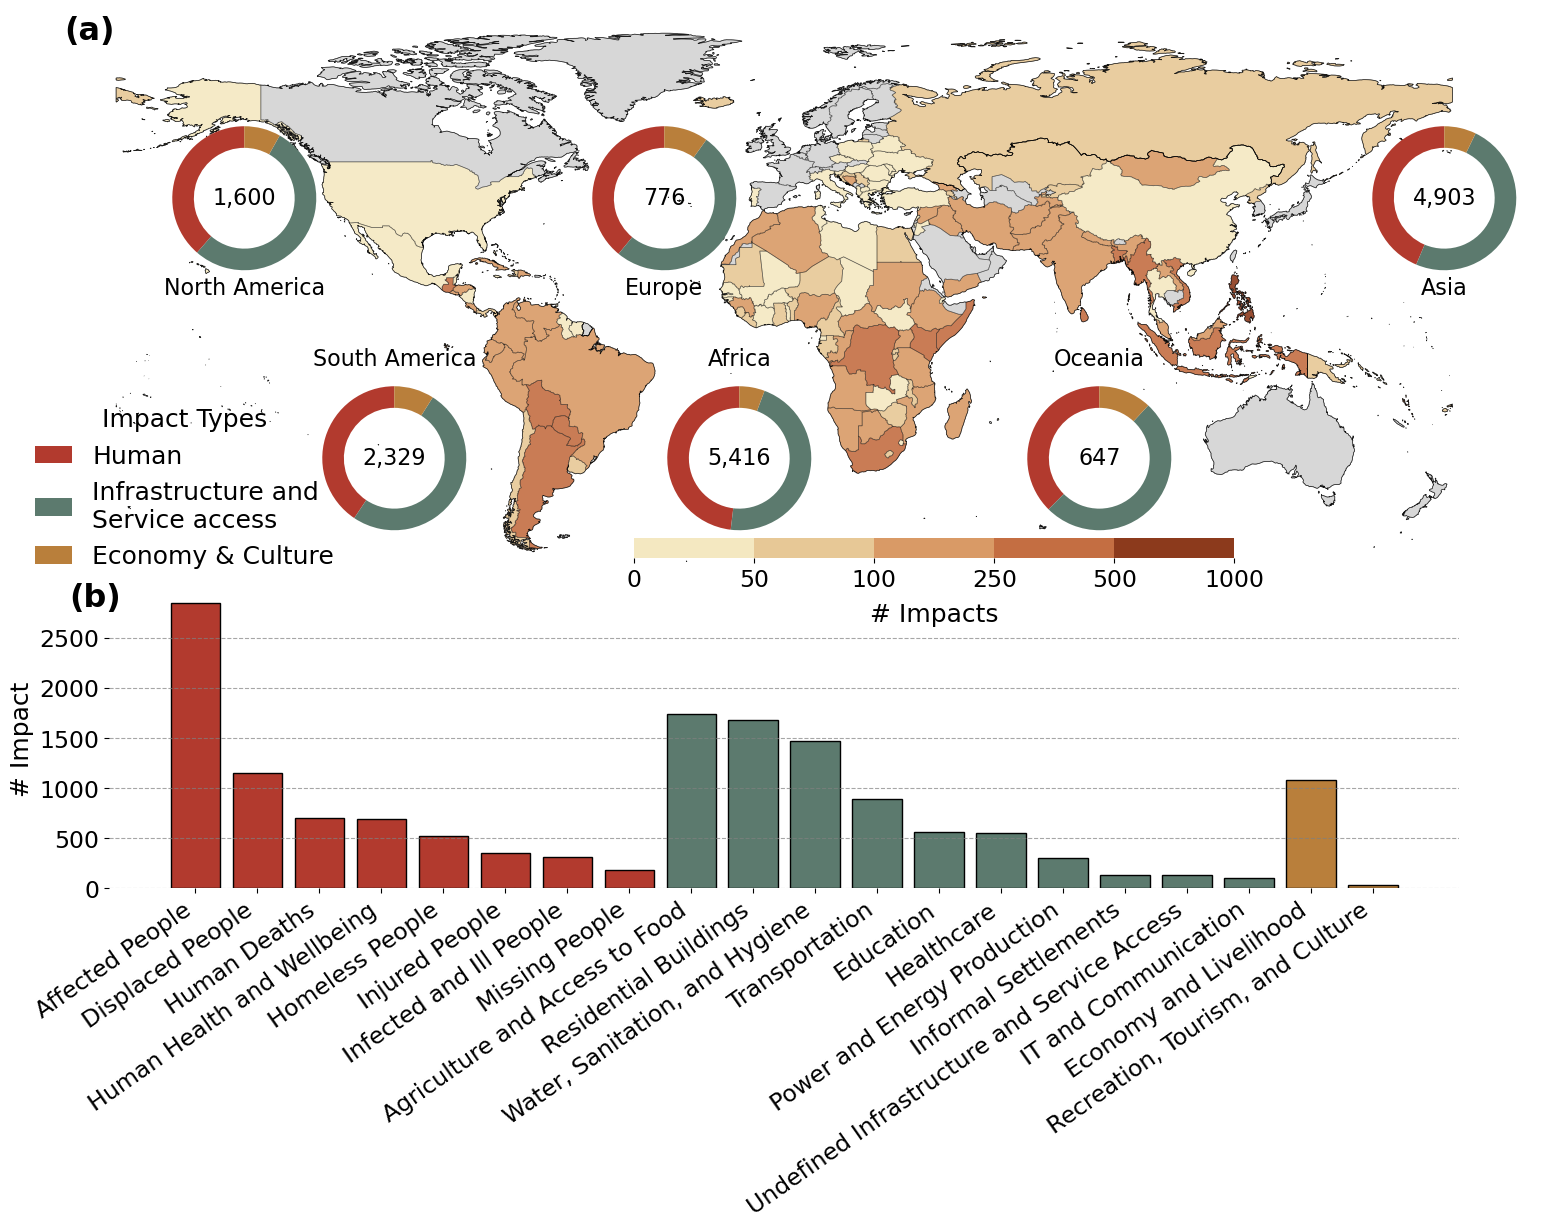

In [42]:
# Step 3: Plot the static choropleth map

# Global font-size control
FONT_SIZE = 18
FS_TITLE = FONT_SIZE + 1
FS_LABEL = FONT_SIZE 
FS_TICK = FONT_SIZE - 1
FS_SMALL = FONT_SIZE - 4
FS_NUMBER_MAP = FONT_SIZE - 2

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

ax.set_ylim(-60, 90)

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.4)

colors_5 = ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"]
cmap_5 = ListedColormap(colors_5, name="warm_earth_5")

values = world_impact["impact_count"].dropna()

# 5 classes -> 6 boundaries
bounds = [0, 50, 100, 250, 500, 1000]

norm = BoundaryNorm(bounds, cmap_5.N)

world_impact.plot(
    column="impact_count",
    ax=ax,
    cmap=cmap_5,
    norm=norm,
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    alpha=0.9
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap_5, norm=norm)
sm._A = []
cbar_ax = fig.add_axes([0.4, 0.23, 0.4, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=FS_TICK)
cbar.outline.set_visible(False)
cbar.set_label("# Impacts", fontsize=FS_LABEL, labelpad=8)

ax.set_axis_off()

# Prepare continent data
all_report_impact_count_clean = all_report_impact_maintype_count.reset_index()
all_report_impact_count_clean['continent'] = all_report_impact_count_clean['iso_code'].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)

continent_shapes = world_impact.dissolve(by='CONTINENT')
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)

# Add continents boundaries
continent_shapes.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=0.8)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

# Calculate impact percentages per continent
continent_impact_counts = (
    all_report_impact_count_clean
    .groupby(['continent', 'impact_main_type'])['impact_count']
    .sum()
    .unstack(fill_value=0)
)

# Order columns and calculate percentages
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)
continent_impact_pct = continent_impact_counts.div(continent_impact_counts.sum(axis=1), axis=0) * 100

# Continent position offsets for donut charts
continent_offsets = {
    'Africa': (0.38, 0.24),
    'Asia': (0.85, 0.50),
    'Europe': (0.33, 0.50),
    'North America': (0.05, 0.50),
    'Oceania': (0.62, 0.24),
    'South America': (0.15, 0.24)
}

# Plot donut charts for each continent
for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_pct.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    # Get position offsets
    x_value, y_value = continent_offsets.get(continent, (0, 0))

    # Create axis for donut chart
    ax_donut = fig.add_axes([x_value, y_value, 0.18, 0.18])
    ax_donut.set_facecolor('white')
    ax_donut.patch.set_alpha(0.7)

    # Impact data
    impact_data = continent_impact_pct.loc[continent]
    impact_data = impact_data[impact_data > 0]
    impact_labels = impact_data.index
    impact_sizes = impact_data.values
    impact_colors = [impact_colormap.get(label, '#BBBBBB') for label in impact_labels]

    # Impact donut
    wedges_impact, _ = ax_donut.pie(
        impact_sizes,
        colors=impact_colors,
        startangle=90,
        wedgeprops=dict(width=0.3)
    )

    # Add total impact value
    total_impacts = int(continent_impact_counts.loc[continent].sum())
    ax_donut.text(
        0, 0, f'{total_impacts:,}',
        ha='center', va='center',
        fontsize=FS_NUMBER_MAP, color='black'
    )

    # Keep this block for potential future wedge annotations
    for i, (size, wedge) in enumerate(zip(impact_sizes, wedges_impact)):
        if size >= 10:
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = 0.5 * np.cos(np.radians(angle))
            y = 0.5 * np.sin(np.radians(angle))

    # Remove axis frame
    ax_donut.set_frame_on(False)
    ax_donut.set_xticks([])
    ax_donut.set_yticks([])

    if continent in ['North America', 'Asia', 'Europe']:
        ax_donut.set_title(continent, fontsize=FS_NUMBER_MAP, pad=2, y=-0.05)
    else:
        ax_donut.set_title(continent, fontsize=FS_NUMBER_MAP, pad=2, y=1)

# Add impact legend for impact types
wrapped_labels = {
    impact: '\n'.join(textwrap.wrap(impact, width=20))
    for impact in impact_order if impact in impact_colormap
}

legend_ax = fig.add_axes([0, 0.1, 0.2, 0.4]) ### LEGEND POSITION
legend_ax.set_facecolor('white')
legend_ax.patch.set_alpha(0.8)

# Create legend elements with wrapped labels
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=impact_colormap[impact], label=wrapped_labels[impact])
    for impact in impact_order if impact in impact_colormap
]

# Add legend
legend_ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=FS_LABEL,
    title='Impact Types',
    title_fontsize=FS_LABEL,
    ncol=1,
    columnspacing=1.5,
    handlelength=1.5
)
legend_ax.set_axis_off()

# ------------------------------------------------------------------
# Impact subtype barplot: vertical and fully on the right
# ------------------------------------------------------------------
# Add barplot of impact subtypes
barplot_subtype_ax = fig.add_axes([0.05, -0.1, 0.9, 0.3]) ######## LOCATION OF THE IMPACT SUBTYPE BARPLOT  
barplot_subtype_ax.set_facecolor('white')
barplot_subtype_ax.patch.set_alpha(0)

impact_order = list(impact_colormap.keys())

all_reports_impactsubtype['impact_main_type'] = (
    pd.Categorical(
        all_reports_impactsubtype['impact_main_type'],
        categories=impact_order,
        ordered=True
    )
)

# Sort by category then subtype count
all_reports_impactsubtype_sorted = (
    all_reports_impactsubtype
    .sort_values(by=["impact_main_type", "impact_subtype_count"], ascending=[True, False])
    .reset_index(drop=True)
)

barplot_subtype_ax.bar(
    x=all_reports_impactsubtype_sorted['impactSubtype'],
    height=all_reports_impactsubtype_sorted['impact_subtype_count'],
    color=all_reports_impactsubtype_sorted['color'],
    edgecolor='black'
)

wrapped_labels = [
    '\n'.join(textwrap.wrap(label, width=60))
    for label in all_reports_impactsubtype_sorted['impactSubtype']
]
barplot_subtype_ax.set_xticks(range(len(all_reports_impactsubtype_sorted)))
barplot_subtype_ax.set_xticklabels(wrapped_labels, rotation=35, ha='right', fontsize=FS_SMALL)

barplot_subtype_ax.tick_params(axis='x', labelsize=FS_TICK)#FS_SMALL)
barplot_subtype_ax.tick_params(axis='y', labelsize=FS_TICK)
for spine in barplot_subtype_ax.spines.values():
    spine.set_visible(False)
barplot_subtype_ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.7)
barplot_subtype_ax.set_ylabel('# Impact', fontsize=FS_LABEL)

# Add (a) and (b) labels
ax.text(
    0.01, 0.99, "(a)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=FS_TITLE + 4,
    fontweight="bold"
)

barplot_subtype_ax.text(
    -0.03, 1.02, "(b)",
    transform=barplot_subtype_ax.transAxes,
    ha="left",
    va="top",
    fontsize=FS_TITLE + 4,
    fontweight="bold"
)

plt.tight_layout()
fig.savefig(path_save_fig / f"impact_map.png", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_map.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_map.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_5480\3864768662.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


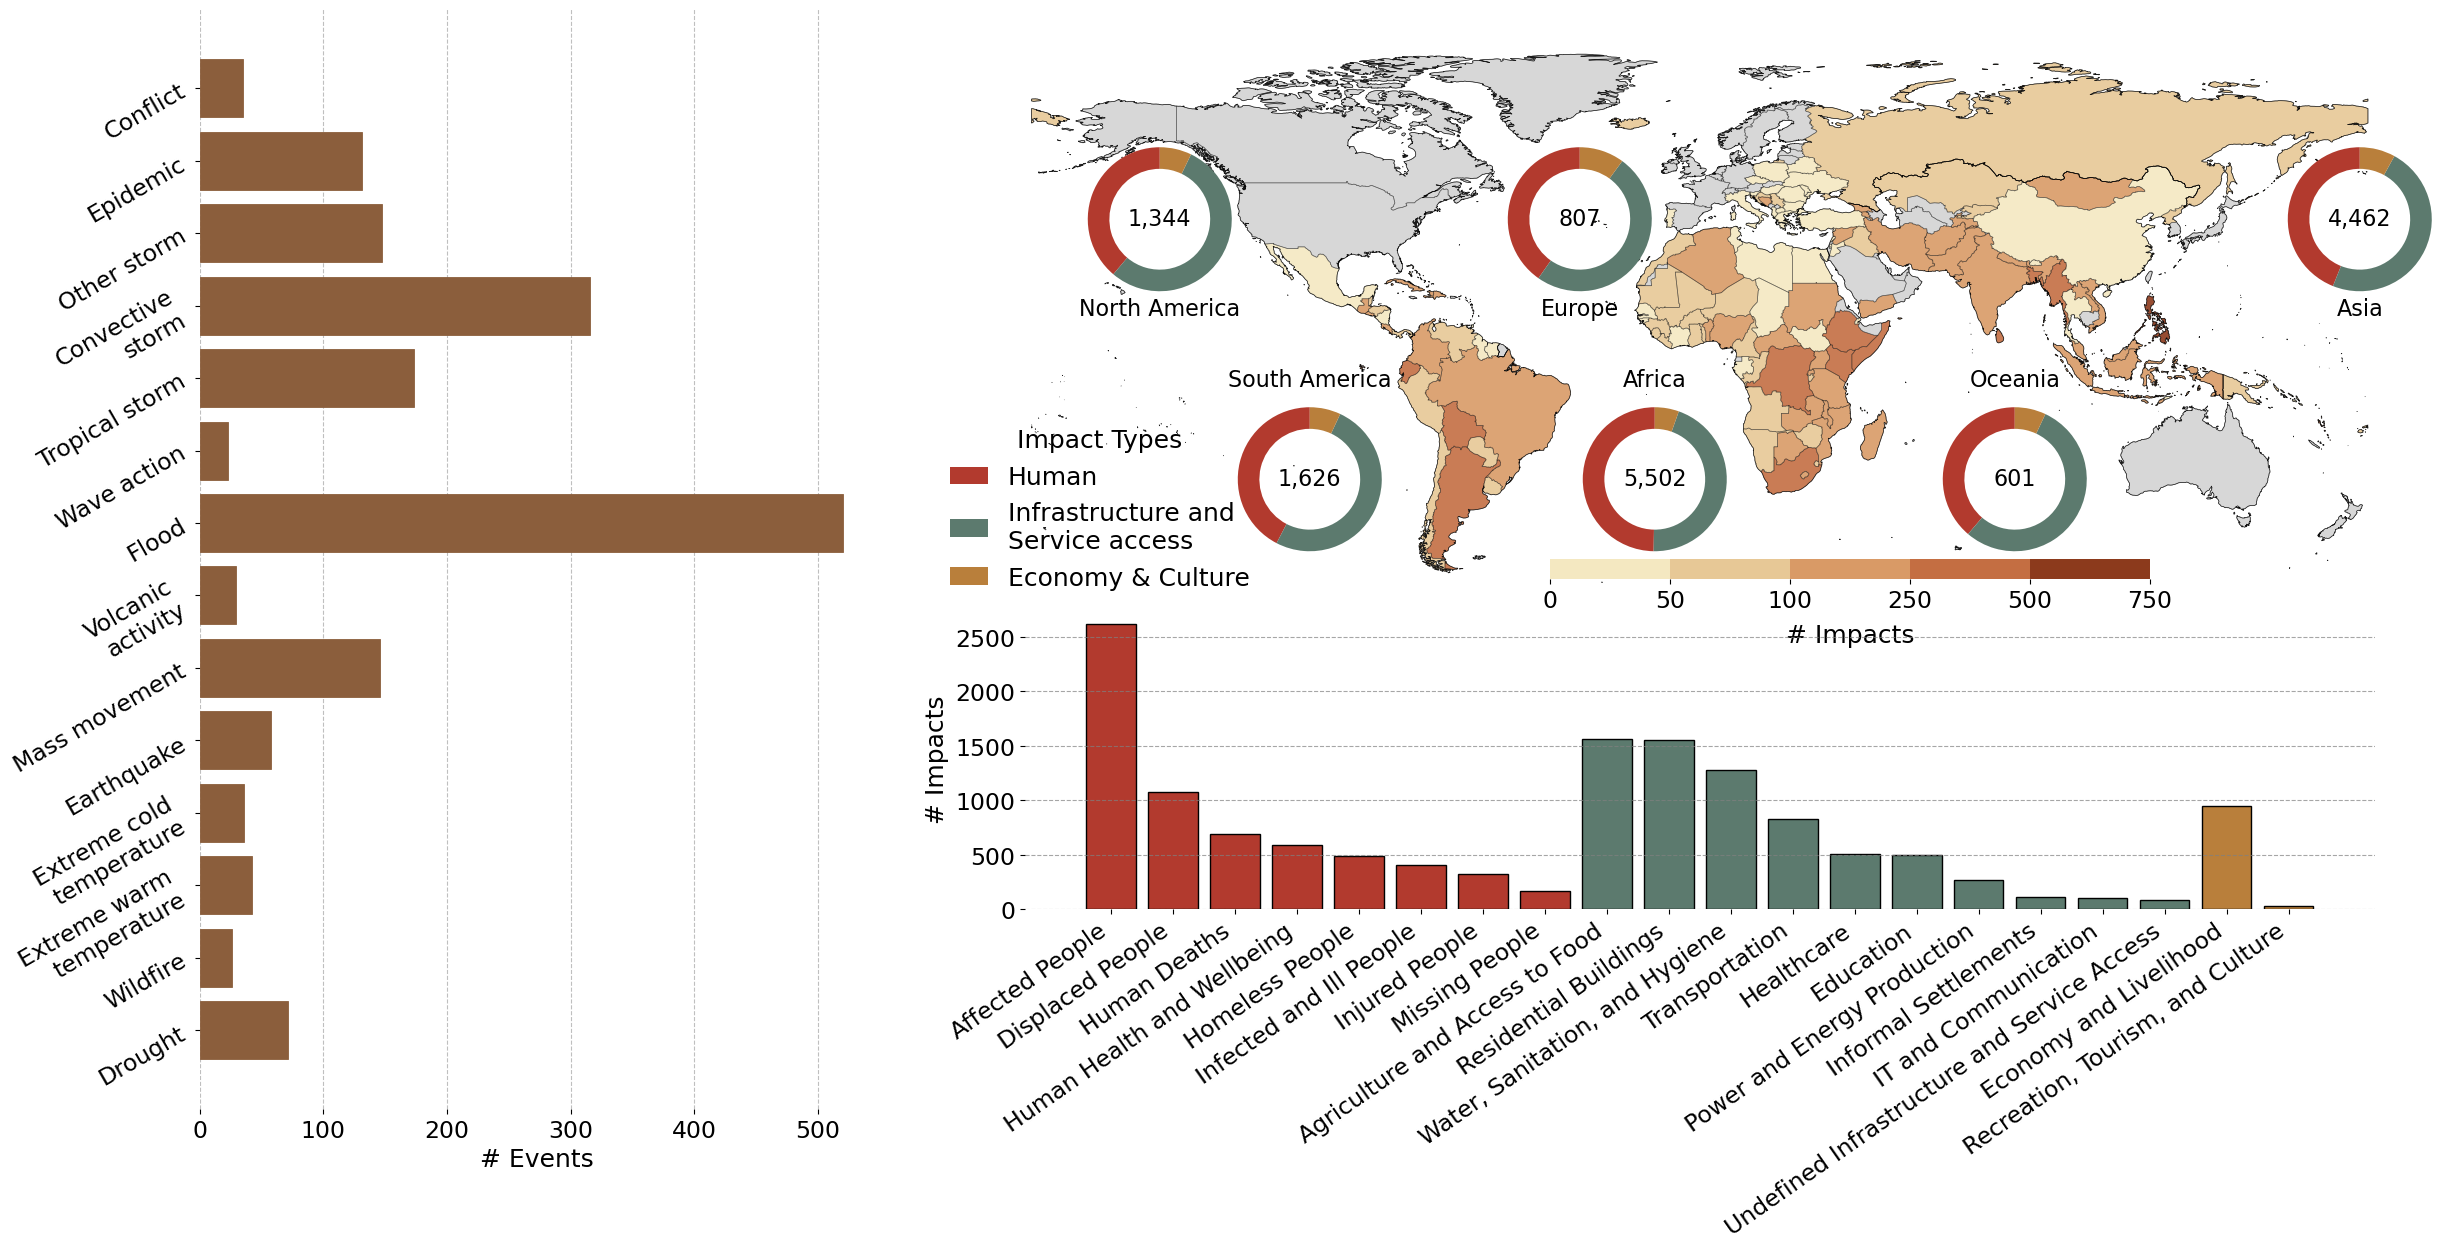

In [59]:
# Step 3: Plot the static choropleth map

# Global font-size control
FONT_SIZE = 18
FS_TITLE = FONT_SIZE + 1
FS_LABEL = FONT_SIZE 
FS_TICK = FONT_SIZE - 1
FS_SMALL = FONT_SIZE - 4
FS_NUMBER_MAP = FONT_SIZE - 2

# Brown palette for hazard count bars (single-hue look)
HAZARD_BROWN = "#8B5E3C"
HAZARD_BROWN_LIGHT = "#B08968"

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

ax.set_ylim(-60, 90)

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.4)

colors_5 = ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"]
cmap_5 = ListedColormap(colors_5, name="warm_earth_5")

values = world_impact["impact_count"].dropna()

# 5 classes -> 6 boundaries
bounds = [0, 50, 100, 250, 500, 750]

norm = BoundaryNorm(bounds, cmap_5.N)

world_impact.plot(
    column="impact_count",
    ax=ax,
    cmap=cmap_5,
    norm=norm,
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    alpha=0.9
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap_5, norm=norm)
sm._A = []
cbar_ax = fig.add_axes([0.4, 0.23, 0.4, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=FS_TICK)
cbar.outline.set_visible(False)
cbar.set_label("# Impacts", fontsize=FS_LABEL, labelpad=8)

ax.set_axis_off()

# Prepare continent data
all_report_impact_count_clean = all_report_impact_maintype_count.reset_index()
all_report_impact_count_clean['continent'] = all_report_impact_count_clean['iso_code'].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)

continent_shapes = world_impact.dissolve(by='CONTINENT')
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)

# Add continents boundaries
continent_shapes.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=0.8)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

# Calculate impact percentages per continent
continent_impact_counts = (
    all_report_impact_count_clean
    .groupby(['continent', 'impact_main_type'])['impact_count']
    .sum()
    .unstack(fill_value=0)
)

# Order columns and calculate percentages
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)
continent_impact_pct = continent_impact_counts.div(continent_impact_counts.sum(axis=1), axis=0) * 100

# Continent position offsets for donut charts
continent_offsets = {
    'Africa': (0.38, 0.24),
    'Asia': (0.85, 0.50),
    'Europe': (0.33, 0.50),
    'North America': (0.05, 0.50),
    'Oceania': (0.62, 0.24),
    'South America': (0.15, 0.24)
}

# Plot donut charts for each continent
for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_pct.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    # Get position offsets
    x_value, y_value = continent_offsets.get(continent, (0, 0))

    # Create axis for donut chart
    ax_donut = fig.add_axes([x_value, y_value, 0.18, 0.18])
    ax_donut.set_facecolor('white')
    ax_donut.patch.set_alpha(0.7)

    # Impact data
    impact_data = continent_impact_pct.loc[continent]
    impact_data = impact_data[impact_data > 0]
    impact_labels = impact_data.index
    impact_sizes = impact_data.values
    impact_colors = [impact_colormap.get(label, '#BBBBBB') for label in impact_labels]

    # Impact donut
    wedges_impact, _ = ax_donut.pie(
        impact_sizes,
        colors=impact_colors,
        startangle=90,
        wedgeprops=dict(width=0.3)
    )

    # Add total impact value
    total_impacts = int(continent_impact_counts.loc[continent].sum())
    ax_donut.text(
        0, 0, f'{total_impacts:,}',
        ha='center', va='center',
        fontsize=FS_NUMBER_MAP, color='black'
    )

    # Keep this block for potential future wedge annotations
    for i, (size, wedge) in enumerate(zip(impact_sizes, wedges_impact)):
        if size >= 10:
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = 0.5 * np.cos(np.radians(angle))
            y = 0.5 * np.sin(np.radians(angle))

    # Remove axis frame
    ax_donut.set_frame_on(False)
    ax_donut.set_xticks([])
    ax_donut.set_yticks([])

    if continent in ['North America', 'Asia', 'Europe']:
        ax_donut.set_title(continent, fontsize=FS_NUMBER_MAP, pad=2, y=-0.05)
    else:
        ax_donut.set_title(continent, fontsize=FS_NUMBER_MAP, pad=2, y=1)

# ------------------------------------------------------------------
# Hazard barplot: vertical and fully on the right
# ------------------------------------------------------------------
# Aggregate hazards at appeal level first
hazard_by_appeal = (
    df_llm_all_geo[["appealCode", "hazards"]]
    .explode("hazards")
    .dropna(subset=["hazards"])
    .copy()
)
hazard_by_appeal["hazards"] = hazard_by_appeal["hazards"].astype(str).str.strip()
hazard_by_appeal = hazard_by_appeal.loc[hazard_by_appeal["hazards"] != ""]
hazard_by_appeal = hazard_by_appeal.loc[hazard_by_appeal["hazards"].isin(hazard_order)]


appeal_hazard_sets = (
    hazard_by_appeal
    .groupby("appealCode")["hazards"]
    .agg(lambda s: set(s))
    .reset_index(name="hazard_set")
)
# appeal_hazard_sets["is_compound"] = appeal_hazard_sets["hazard_set"].apply(lambda hs: len(hs) > 1)

hazard_appeal_long = (
    appeal_hazard_sets
    .explode("hazard_set")
    .rename(columns={"hazard_set": "hazard"})
)

hazard_total_counts = hazard_appeal_long.groupby("hazard")["appealCode"].nunique()
# hazard_compound_counts = (
#     hazard_appeal_long
#     .loc[hazard_appeal_long["is_compound"]]
#     .groupby("hazard")["appealCode"]
#     .nunique()
# )
hazard_plot_order = [h for h in hazard_order if h in hazard_total_counts.index]
hazard_plot_order += sorted([h for h in hazard_total_counts.index if h not in hazard_plot_order])

total_vals = np.array([hazard_total_counts.get(h, 0) for h in hazard_plot_order], dtype=float)
compound_vals = np.array([hazard_compound_counts.get(h, 0) for h in hazard_plot_order], dtype=float)
single_vals = total_vals - compound_vals

hazard_colors = [hazard_colormap.get(h, "#BBBBBB") for h in hazard_plot_order]

# Right-side inset axis (horizontal bars)
ax_hazard = fig.add_axes([-0.5, -0.3, 0.45, 1.1]) ######## LOCATION OF THE HAZARD BARPLOT
ax_hazard.set_facecolor("white")
ax_hazard.patch.set_alpha(0.9)

y_pos = np.arange(len(hazard_plot_order))
ax_hazard.barh(
    y_pos,
    single_vals+compound_vals,
    color=HAZARD_BROWN,
    edgecolor=HAZARD_BROWN,
    linewidth=0.6
)
# ax_hazard.barh(
#     y_pos,
#     compound_vals,
#     left=single_vals,
#     color=hazard_colors,
#     edgecolor="black",
#     linewidth=0.6,
#     hatch="///",
#     alpha=0.55,
#     label="Compound-event appeals"
# )

wrapped_hazard_labels = ["\n".join(textwrap.wrap(h, width=14)) for h in hazard_plot_order]
ax_hazard.set_yticks(y_pos)
ax_hazard.set_yticklabels(wrapped_hazard_labels, rotation=30, ha='right', fontsize=FS_TICK)
ax_hazard.tick_params(axis="x", labelsize=FS_TICK)
ax_hazard.set_xlabel("# Events", fontsize=FS_LABEL)
# ax_hazard.set_title("Hazard Count by Type", fontsize=FS_TITLE, pad=6)
ax_hazard.xaxis.grid(True, linestyle='--', color='gray', alpha=0.5)
ax_hazard.set_axisbelow(True)
# ax_hazard.legend(loc="upper right", fontsize=FS_SMALL, frameon=False)
for spine in ax_hazard.spines.values():
    spine.set_visible(False)

# Add impact legend for impact types
wrapped_labels = {
    impact: '\n'.join(textwrap.wrap(impact, width=20))
    for impact in impact_order if impact in impact_colormap
}

legend_ax = fig.add_axes([0, 0.1, 0.2, 0.4]) ### LEGEND POSITION
legend_ax.set_facecolor('white')
legend_ax.patch.set_alpha(0.8)

# Create legend elements with wrapped labels
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=impact_colormap[impact], label=wrapped_labels[impact])
    for impact in impact_order if impact in impact_colormap
]

# Add legend
legend_ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=FS_LABEL,
    title='Impact Types',
    title_fontsize=FS_LABEL,
    ncol=1,
    columnspacing=1.5,
    handlelength=1.5
)
legend_ax.set_axis_off()

# ------------------------------------------------------------------
# Impact subtype barplot: vertical and fully on the right
# ------------------------------------------------------------------
# Add barplot of impact subtypes
barplot_subtype_ax = fig.add_axes([0.05, -0.1, 0.9, 0.3]) ######## LOCATION OF THE IMPACT SUBTYPE BARPLOT  
barplot_subtype_ax.set_facecolor('white')
barplot_subtype_ax.patch.set_alpha(0)

impact_order = list(impact_colormap.keys())

all_reports_impactsubtype['impact_main_type'] = (
    pd.Categorical(
        all_reports_impactsubtype['impact_main_type'],
        categories=impact_order,
        ordered=True
    )
)

# Sort by category then subtype count
all_reports_impactsubtype_sorted = (
    all_reports_impactsubtype
    .sort_values(by=["impact_main_type", "impact_subtype_count"], ascending=[True, False])
    .reset_index(drop=True)
)

barplot_subtype_ax.bar(
    x=all_reports_impactsubtype_sorted['impactSubtype'],
    height=all_reports_impactsubtype_sorted['impact_subtype_count'],
    color=all_reports_impactsubtype_sorted['color'],
    edgecolor='black'
)

wrapped_labels = [
    '\n'.join(textwrap.wrap(label, width=60))
    for label in all_reports_impactsubtype_sorted['impactSubtype']
]
barplot_subtype_ax.set_xticks(range(len(all_reports_impactsubtype_sorted)))
barplot_subtype_ax.set_xticklabels(wrapped_labels, rotation=35, ha='right', fontsize=FS_SMALL)

barplot_subtype_ax.tick_params(axis='x', labelsize=FS_TICK)#FS_SMALL)
barplot_subtype_ax.tick_params(axis='y', labelsize=FS_TICK)
for spine in barplot_subtype_ax.spines.values():
    spine.set_visible(False)
barplot_subtype_ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.7)
barplot_subtype_ax.set_ylabel('# Impacts', fontsize=FS_LABEL)

plt.tight_layout()
fig.savefig(path_save_fig / f"impact_hazard_map.png", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_hazard_map.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_hazard_map.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_4724\3527859902.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


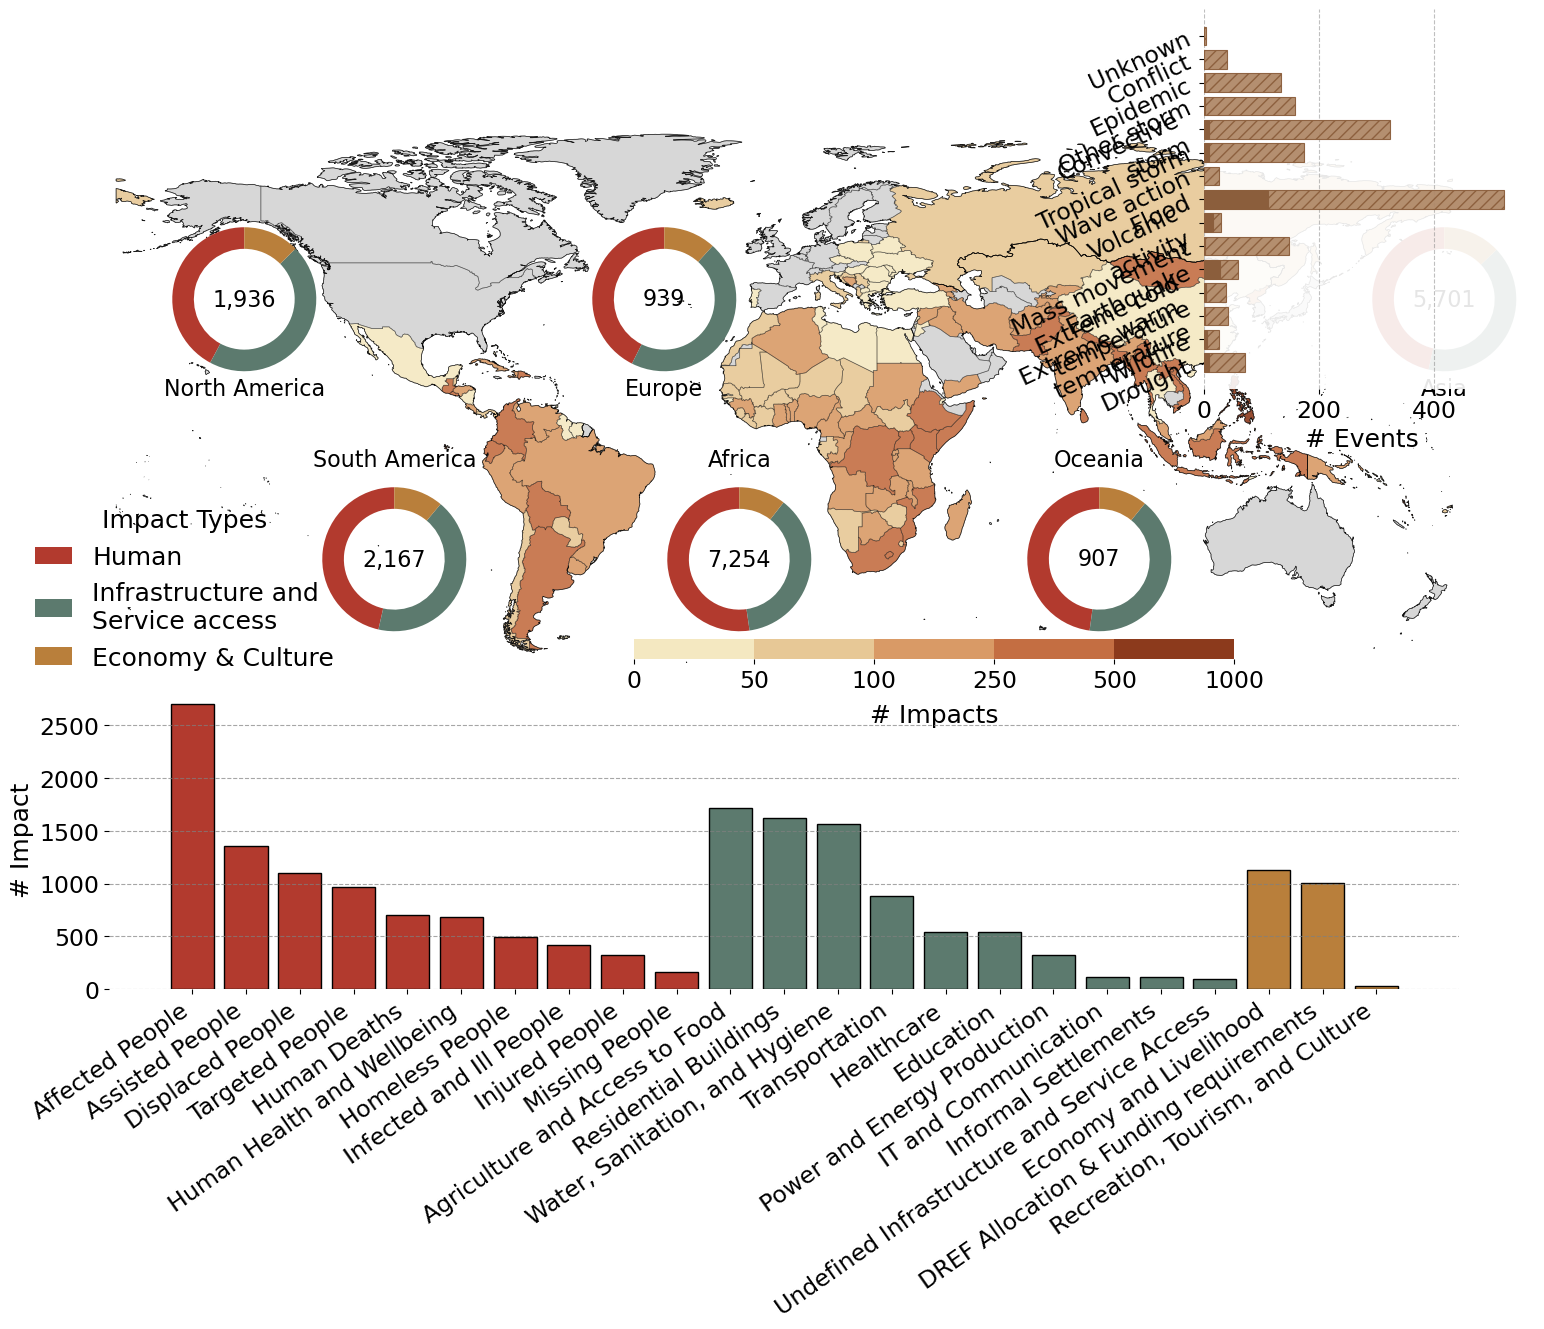

In [95]:
# Alternative map version: hazard count barplot in a single brown palette

# Global font-size control
FONT_SIZE = 18
FS_TITLE = FONT_SIZE + 1
FS_LABEL = FONT_SIZE
FS_TICK = FONT_SIZE - 1
FS_SMALL = FONT_SIZE - 4
FS_NUMBER_MAP = FONT_SIZE - 2

# Brown palette for hazard count bars (single-hue look)
HAZARD_BROWN = "#8B5E3C"
HAZARD_BROWN_LIGHT = "#B08968"

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

ax.set_ylim(-60, 90)
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.4)

colors_5 = ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"]
cmap_5 = ListedColormap(colors_5, name="warm_earth_5")

bounds = [0, 50, 100, 250, 500, 1000]
norm = BoundaryNorm(bounds, cmap_5.N)

world_impact.plot(
    column="impact_count",
    ax=ax,
    cmap=cmap_5,
    norm=norm,
    legend=False,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    alpha=0.9,
)

sm = cm.ScalarMappable(cmap=cmap_5, norm=norm)
sm._A = []
cbar_ax = fig.add_axes([0.4, 0.23, 0.4, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=FS_TICK)
cbar.outline.set_visible(False)
cbar.set_label("# Impacts", fontsize=FS_LABEL, labelpad=8)

ax.set_axis_off()

all_report_impact_count_clean = all_report_impact_maintype_count.reset_index()
all_report_impact_count_clean["continent"] = all_report_impact_count_clean["iso_code"].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)

continent_shapes = world_impact.dissolve(by="CONTINENT")
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)
continent_shapes.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.8)

continents_plot = ["Africa", "Asia", "Europe", "North America", "Oceania", "South America"]

continent_impact_counts = (
    all_report_impact_count_clean
    .groupby(["continent", "impact_main_type"])["impact_count"]
    .sum()
    .unstack(fill_value=0)
)
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)
continent_impact_pct = continent_impact_counts.div(continent_impact_counts.sum(axis=1), axis=0) * 100

continent_offsets = {
    "Africa": (0.38, 0.24),
    "Asia": (0.85, 0.50),
    "Europe": (0.33, 0.50),
    "North America": (0.05, 0.50),
    "Oceania": (0.62, 0.24),
    "South America": (0.15, 0.24),
}

for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_pct.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    x_value, y_value = continent_offsets.get(continent, (0, 0))
    ax_donut = fig.add_axes([x_value, y_value, 0.18, 0.18])
    ax_donut.set_facecolor("white")
    ax_donut.patch.set_alpha(0.7)

    impact_data = continent_impact_pct.loc[continent]
    impact_data = impact_data[impact_data > 0]
    impact_sizes = impact_data.values
    impact_colors = [impact_colormap.get(label, "#BBBBBB") for label in impact_data.index]

    wedges_impact, _ = ax_donut.pie(
        impact_sizes,
        colors=impact_colors,
        startangle=90,
        wedgeprops=dict(width=0.3),
    )

    total_impacts = int(continent_impact_counts.loc[continent].sum())
    ax_donut.text(
        0,
        0,
        f"{total_impacts:,}",
        ha="center",
        va="center",
        fontsize=FS_NUMBER_MAP,
        color="black",
    )

    for i, (size, wedge) in enumerate(zip(impact_sizes, wedges_impact)):
        if size >= 10:
            angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
            x = 0.5 * np.cos(np.radians(angle))
            y = 0.5 * np.sin(np.radians(angle))

    ax_donut.set_frame_on(False)
    ax_donut.set_xticks([])
    ax_donut.set_yticks([])

    if continent in ["North America", "Asia", "Europe"]:
        ax_donut.set_title(continent, fontsize=FS_NUMBER_MAP, pad=2, y=-0.05)
    else:
        ax_donut.set_title(continent, fontsize=FS_NUMBER_MAP, pad=2, y=1)

# Hazard count by type (single brown palette)
hazard_by_appeal = (
    df_llm_all_geo[["appealCode", "hazards"]]
    .explode("hazards")
    .dropna(subset=["hazards"])
    .copy()
)
hazard_by_appeal["hazards"] = hazard_by_appeal["hazards"].astype(str).str.strip()
hazard_by_appeal = hazard_by_appeal.loc[hazard_by_appeal["hazards"] != ""]

appeal_hazard_sets = (
    hazard_by_appeal
    .groupby("appealCode")["hazards"]
    .agg(lambda s: set(s))
    .reset_index(name="hazard_set")
)
appeal_hazard_sets["is_compound"] = appeal_hazard_sets["hazard_set"].apply(lambda hs: len(hs) > 1)

hazard_appeal_long = (
    appeal_hazard_sets
    .explode("hazard_set")
    .rename(columns={"hazard_set": "hazard"})
)

hazard_total_counts = hazard_appeal_long.groupby("hazard")["appealCode"].nunique()
hazard_compound_counts = (
    hazard_appeal_long
    .loc[hazard_appeal_long["is_compound"]]
    .groupby("hazard")["appealCode"]
    .nunique()
)

hazard_plot_order = [h for h in hazard_order if h in hazard_total_counts.index]
hazard_plot_order += sorted([h for h in hazard_total_counts.index if h not in hazard_plot_order])

total_vals = np.array([hazard_total_counts.get(h, 0) for h in hazard_plot_order], dtype=float)
compound_vals = np.array([hazard_compound_counts.get(h, 0) for h in hazard_plot_order], dtype=float)
single_vals = total_vals - compound_vals

ax_hazard = fig.add_axes([0.78, 0.50, 0.21, 0.38])
ax_hazard.set_facecolor("white")
ax_hazard.patch.set_alpha(0.9)

y_pos = np.arange(len(hazard_plot_order))
ax_hazard.barh(
    y_pos,
    single_vals,
    color=HAZARD_BROWN,
    edgecolor=HAZARD_BROWN,
    linewidth=0.8,
)
ax_hazard.barh(
    y_pos,
    compound_vals,
    left=single_vals,
    color=HAZARD_BROWN_LIGHT,
    edgecolor=HAZARD_BROWN,
    linewidth=0.8,
    hatch="///",
    alpha=0.95,
)

wrapped_hazard_labels = ["\n".join(textwrap.wrap(h, width=14)) for h in hazard_plot_order]
ax_hazard.set_yticks(y_pos)
ax_hazard.set_yticklabels(wrapped_hazard_labels, rotation=25, ha="right", fontsize=FS_TICK)
ax_hazard.tick_params(axis="x", labelsize=FS_TICK)
ax_hazard.set_xlabel("# Events", fontsize=FS_LABEL)
ax_hazard.xaxis.grid(True, linestyle="--", color="gray", alpha=0.5)
ax_hazard.set_axisbelow(True)
for spine in ax_hazard.spines.values():
    spine.set_visible(False)

# Impact legend
wrapped_labels = {
    impact: "\n".join(textwrap.wrap(impact, width=20))
    for impact in impact_order
    if impact in impact_colormap
}

legend_ax = fig.add_axes([0, 0.1, 0.2, 0.4])
legend_ax.set_facecolor("white")
legend_ax.patch.set_alpha(0.8)
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=impact_colormap[impact], label=wrapped_labels[impact])
    for impact in impact_order
    if impact in impact_colormap
]
legend_ax.legend(
    handles=legend_elements,
    loc="center",
    frameon=False,
    fontsize=FS_LABEL,
    title="Impact Types",
    title_fontsize=FS_LABEL,
    ncol=1,
    columnspacing=1.5,
    handlelength=1.5,
)
legend_ax.set_axis_off()

# Impact subtype barplot
barplot_subtype_ax = fig.add_axes([0.05, -0.1, 0.9, 0.3])
barplot_subtype_ax.set_facecolor("white")
barplot_subtype_ax.patch.set_alpha(0)

impact_order = list(impact_colormap.keys())
all_reports_impactsubtype["impact_main_type"] = pd.Categorical(
    all_reports_impactsubtype["impact_main_type"],
    categories=impact_order,
    ordered=True,
)
all_reports_impactsubtype_sorted = (
    all_reports_impactsubtype
    .sort_values(by=["impact_main_type", "impact_subtype_count"], ascending=[True, False])
    .reset_index(drop=True)
)

barplot_subtype_ax.bar(
    x=all_reports_impactsubtype_sorted["impactSubtype"],
    height=all_reports_impactsubtype_sorted["impact_subtype_count"],
    color=all_reports_impactsubtype_sorted["color"],
    edgecolor="black",
)

wrapped_labels = [
    "\n".join(textwrap.wrap(label, width=60))
    for label in all_reports_impactsubtype_sorted["impactSubtype"]
]
barplot_subtype_ax.set_xticks(range(len(all_reports_impactsubtype_sorted)))
barplot_subtype_ax.set_xticklabels(wrapped_labels, rotation=35, ha="right", fontsize=FS_SMALL)
barplot_subtype_ax.tick_params(axis="x", labelsize=FS_TICK)
barplot_subtype_ax.tick_params(axis="y", labelsize=FS_TICK)
for spine in barplot_subtype_ax.spines.values():
    spine.set_visible(False)
barplot_subtype_ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)
barplot_subtype_ax.set_ylabel("# Impact", fontsize=FS_LABEL)

plt.tight_layout()
# fig.savefig(path_save_fig / f"impact_map_brown_hazards.png", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"impact_map_brown_hazards.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"impact_map_brown_hazards.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()